# 09/21 Optimizations

Before is the serial millisecond loop from `baseline.ipynb`. After is `OptimizedProcessor`: each array is re-referenced with a cached block matrix, and the reverse FIR is one multiply across channels. Spikes are also stored as events and a sparse matrix. An optional 30 kHz to 15 kHz decimation is measured separately.

The recording here is synthetic, so the notebook runs without the 706 MiB example file. Lossless comparisons use the same samples, the same common-average groups, and the same thresholds. Decimation is a separate, lossy comparison.

In [1]:
%matplotlib inline
import contextlib
import io
import time

import matplotlib.pyplot as plt
import numpy as np

from optimizations import (
    AntiAliasDecimator,
    OptimizedProcessor,
    select_gpu_device,
)
from utils import build_filter, rereference_data

SAMPLE_RATE = 30_000
SAMPLES_PER_MS = 30
GROUP_SIZE = 64


## Synthetic recording

Each group of 64 channels is one array, re-referenced with a common average. Every 10 ms one channel gets a short negative pulse, which is what the threshold is meant to catch. The rest is Gaussian noise.


In [2]:
def make_recording(n_channels, n_ms, seed=0, spike_every_ms=10, spike_amp=-500.0):
    rng = np.random.default_rng(seed)
    n_samples = n_ms * SAMPLES_PER_MS
    raw = rng.normal(scale=20.0, size=(n_channels, n_samples))
    groups = [
        list(range(start, min(start + GROUP_SIZE, n_channels)))
        for start in range(0, n_channels, GROUP_SIZE)
    ]
    reref_params = np.zeros((n_channels, n_channels))
    for group in groups:
        reref_params[np.ix_(group, group)] = 1.0 / len(group)
    for ms in range(8, n_ms, spike_every_ms):
        channel = (ms // spike_every_ms) % n_channels
        start = ms * SAMPLES_PER_MS + 12
        raw[channel, start:start + 2] = spike_amp
    thresholds = np.full((n_channels, 1), -120.0)
    return raw, reref_params, thresholds, groups


def quiet(fn):
    with contextlib.redirect_stdout(io.StringIO()):
        return fn()


## Before

This is the baseline loop: re-reference the whole array, run the acausal 250-5000 Hz filter, then count one spike per channel if the filtered window crosses threshold.


In [3]:
def run_baseline(raw, reref_params, thresholds):
    n_channels = raw.shape[0]
    n_windows = raw.shape[1] // SAMPLES_PER_MS
    lag = int(round(0.004 * SAMPLE_RATE))
    filter_func, sos, zi, rev_win, rev_zi = build_filter(
        n_channels=n_channels,
        but_low=250,
        but_high=5000,
        causal=False,
        acausal_filter_type="fir",
        acausal_filter_lag=lag,
        fs=SAMPLE_RATE,
    )
    spikes = np.zeros((n_channels, n_windows), dtype=np.int16)
    spike_band = np.zeros((n_channels, n_windows), dtype=np.float32)
    filtered = np.zeros((n_channels, n_windows * SAMPLES_PER_MS), dtype=np.float32)
    rev_buffer = np.full((n_channels, lag + SAMPLES_PER_MS), np.nan, dtype=np.float32)
    filt_buffer = np.zeros((n_channels, SAMPLES_PER_MS), dtype=np.float32)
    thresholds = np.asarray(thresholds).reshape(-1, 1)
    for index in range(n_windows):
        start = index * SAMPLES_PER_MS
        stop = start + SAMPLES_PER_MS
        reref = rereference_data(raw[:, start:stop], reref_params)
        filter_func(reref, filt_buffer, rev_buffer, sos, zi, rev_win, rev_zi)
        filtered[:, start:stop] = filt_buffer
        crossings = (
            (filt_buffer[:, 1:] < thresholds) & (filt_buffer[:, :-1] >= thresholds)
        )
        spikes[:, index] = np.any(crossings, axis=1).astype(np.int16)
        spike_band[:, index] = (10 * np.log10(np.square(filt_buffer))).mean(axis=1)
    return filtered, spikes, spike_band


N_CHANNELS = 128
N_MS = 200
raw, reref_params, thresholds, groups = make_recording(N_CHANNELS, N_MS)
before_filtered, before_spikes, before_sbp = quiet(
    lambda: run_baseline(raw, reref_params, thresholds)
)
print(f"before: {before_spikes.shape[0]} channels, {before_spikes.shape[1]} ms, {int(before_spikes.sum())} spikes")


before: 128 channels, 200 ms, 19 spikes


## After

Same recording. Re-referencing uses one cached `(I - P)` block per array instead of rebuilding the full channel matrix. The reverse FIR is a single multiply. Spikes come back as the dense raster, as `(channel, millisecond)` events, and as a CSR matrix. Decimation stays off in this section.

In [4]:
def run_optimized(raw, reref_params, thresholds, groups, **kwargs):
    defaults = dict(
        per_array_threads=True,
        per_channel_threads=True,
        use_gpu=False,
        decimate=False,
    )
    defaults.update(kwargs)
    with OptimizedProcessor(
        n_channels=raw.shape[0],
        reref_params=reref_params,
        thresholds=thresholds,
        reref_groups=groups,
        sample_rate=SAMPLE_RATE,
        **defaults,
    ) as processor:
        return processor.process_recording(raw)


after = quiet(lambda: run_optimized(raw, reref_params, thresholds, groups))
print(f"after:  {after.spikes.shape[0]} channels, {after.spikes.shape[1]} ms, {int(after.spikes.sum())} spikes")
print(f"events: {after.spike_events.shape[0]}")


after:  128 channels, 200 ms, 19 spikes
events: 19


## Agreement

Lossless means the filtered waveform, the spike raster, and the spike-band power match the baseline. Early milliseconds are NaN while the 4 ms acausal buffer fills, and those NaNs are counted as equal.


In [5]:
filtered_diff = np.nanmax(np.abs(after.filtered - before_filtered))
sbp_diff = np.nanmax(np.abs(after.spike_band_power - before_sbp))
spike_mismatches = int(np.sum(after.spikes != before_spikes))
print(f"max |filtered difference|:     {filtered_diff:.3e}")
print(f"max |spike-band difference|:   {sbp_diff:.3e}")
print(f"spike bin mismatches:          {spike_mismatches} of {before_spikes.size}")
print(f"spikes before / after:         {int(before_spikes.sum())} / {int(after.spikes.sum())}")


max |filtered difference|:     0.000e+00
max |spike-band difference|:   0.000e+00
spike bin mismatches:          0 of 25600
spikes before / after:         19 / 19


## Runtime

Each number is the median of three runs, in milliseconds of wall time per second of neural data. Lower is faster. Real time means finishing a second of data in under 1000 ms of wall time.

  channels                   path   ms wall / s data
        64               baseline              206.3
        64                   fast              117.0
       256               baseline              786.3
       256                   fast              306.8
      1024               baseline             4087.5
      1024                   fast             1085.0
      2048               baseline            14075.8
      2048                   fast             2252.8


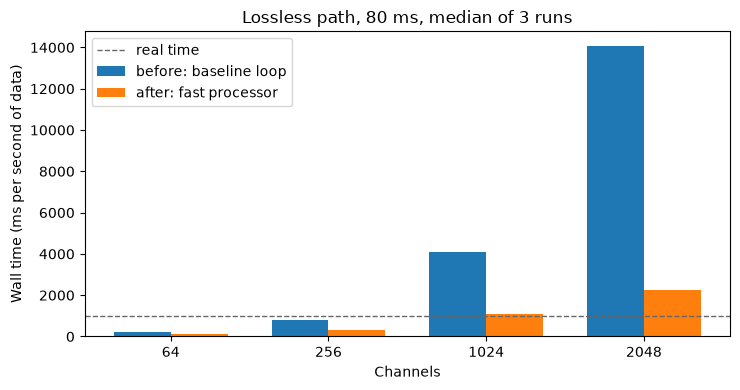

In [6]:
def median_ms_per_second(fn, neural_seconds, repeats=3):
    samples = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        quiet(fn)
        samples.append((time.perf_counter() - t0) / neural_seconds * 1000.0)
    return float(np.median(samples))


timing_ms = 80
timing_rows = []
for n_channels in (64, 256, 1024, 2048):
    data, params, thr, group_list = make_recording(n_channels, timing_ms, seed=1)
    neural_seconds = timing_ms / 1000.0
    before_cost = median_ms_per_second(
        lambda data=data, params=params, thr=thr: run_baseline(data, params, thr),
        neural_seconds,
    )
    after_cost = median_ms_per_second(
        lambda data=data, params=params, thr=thr, group_list=group_list: run_optimized(
            data, params, thr, group_list
        ),
        neural_seconds,
    )
    timing_rows.append((n_channels, "baseline", before_cost))
    timing_rows.append((n_channels, "fast", after_cost))

print(f"{'channels':>10} {'path':>22} {'ms wall / s data':>18}")
for n_channels, path, cost in timing_rows:
    print(f"{n_channels:10d} {path:>22} {cost:18.1f}")

labels = ["64", "256", "1024", "2048"]
before_bars = [row[2] for row in timing_rows if row[1] == "baseline"]
after_bars = [row[2] for row in timing_rows if row[1] == "fast"]
x = np.arange(len(labels))
width = 0.36
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.bar(x - width / 2, before_bars, width, label="before: baseline loop")
ax.bar(x + width / 2, after_bars, width, label="after: fast processor")
ax.axhline(1000, color="0.4", linestyle="--", linewidth=1, label="real time")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_xlabel("Channels")
ax.set_ylabel("Wall time (ms per second of data)")
ax.set_title("Lossless path, 80 ms, median of 3 runs")
ax.legend()
fig.tight_layout()
plt.show()

## Sparse spikes

The dense raster stores a bin for every channel and every millisecond. Events store only the bins that fired. The CSR matrix stores the same nonzeros plus the row index.


In [7]:
dense_bytes = after.spikes.nbytes
event_bytes = after.spike_events.nbytes
sparse = after.spikes_sparse
csr_bytes = sparse.data.nbytes + sparse.indices.nbytes + sparse.indptr.nbytes
n_bins = after.spikes.size
n_spikes = int(after.spikes.sum())
print(f"bins:                 {n_bins}")
print(f"spikes:               {n_spikes} ({100.0 * n_spikes / n_bins:.3f}% of bins)")
print(f"dense int16 raster:   {dense_bytes:,} bytes")
print(f"event list:           {event_bytes:,} bytes  ({dense_bytes / max(event_bytes, 1):.1f}x smaller)")
print(f"CSR matrix:           {csr_bytes:,} bytes  ({dense_bytes / max(csr_bytes, 1):.1f}x smaller)")
print(f"event rows match nnz: {after.spike_events.shape[0] == sparse.nnz}")


bins:                 25600
spikes:               19 (0.074% of bins)
dense int16 raster:   51,200 bytes
event list:           152 bytes  (336.8x smaller)
CSR matrix:           630 bytes  (81.3x smaller)
event rows match nnz: True


## Decimation

Before is the raw 30 kHz tone. Skipping every other sample with no low-pass folds 12 kHz into the 15 kHz stream. After applies the order-8 Butterworth at 6 kHz, then keeps every other sample. A 1 kHz tone is inside the spike band and should come through. A 12 kHz tone should not.


samples in / out:          6000 / 3000 (2x)
1 kHz after decimation:    -0.0 dB vs raw
12 kHz after decimation:   -100.3 dB vs raw
12 kHz naive skip:         +0.0 dB vs raw


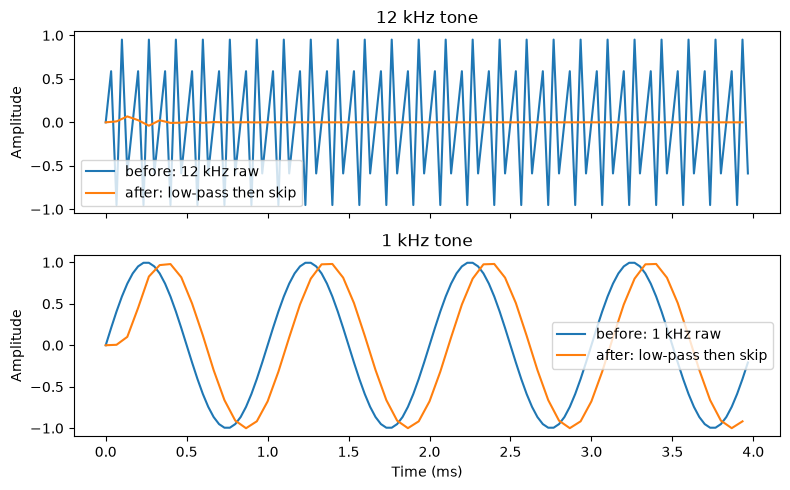

processor input samples/ms:  30
processor output samples/ms: 15
decimated recording:         True, process rate 15000 Hz


In [8]:
duration_s = 0.2
n_samples = int(duration_s * SAMPLE_RATE)
t = np.arange(n_samples) / SAMPLE_RATE
tone_1k = np.sin(2 * np.pi * 1000 * t)
tone_12k = np.sin(2 * np.pi * 12000 * t)
# Drop the filter transient before measuring RMS.
skip = 400

def rms(values):
    return float(np.sqrt(np.mean(np.square(values))))

decimated_1k = AntiAliasDecimator(1, SAMPLE_RATE).process(tone_1k[None, :])[0]
decimated_12k = AntiAliasDecimator(1, SAMPLE_RATE).process(tone_12k[None, :])[0]
naive_12k = tone_12k[::2]

def decibel(out, reference):
    return 20.0 * np.log10(rms(out) / rms(reference))

print(f"samples in / out:          {n_samples} / {decimated_1k.size} ({n_samples / decimated_1k.size:.0f}x)")
print(f"1 kHz after decimation:    {decibel(decimated_1k[skip:], tone_1k[skip * 2:]):+.1f} dB vs raw")
print(f"12 kHz after decimation:   {decibel(decimated_12k[skip:], tone_12k[skip * 2:]):+.1f} dB vs raw")
print(f"12 kHz naive skip:         {decibel(naive_12k[skip:], tone_12k[skip * 2:]):+.1f} dB vs raw")

show_s = 0.004
show_n = int(show_s * SAMPLE_RATE)
time_ms = np.arange(show_n) / SAMPLE_RATE * 1000
time_ms_out = np.arange(show_n // 2) / (SAMPLE_RATE / 2) * 1000
fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
axes[0].plot(time_ms, tone_12k[:show_n], label="before: 12 kHz raw")
axes[0].plot(time_ms_out, decimated_12k[:show_n // 2], label="after: low-pass then skip")
axes[0].set_ylabel("Amplitude")
axes[0].set_title("12 kHz tone")
axes[0].legend()
axes[1].plot(time_ms, tone_1k[:show_n], label="before: 1 kHz raw")
axes[1].plot(time_ms_out, decimated_1k[:show_n // 2], label="after: low-pass then skip")
axes[1].set_xlabel("Time (ms)")
axes[1].set_ylabel("Amplitude")
axes[1].set_title("1 kHz tone")
axes[1].legend()
fig.tight_layout()
plt.show()

lossy_raw, lossy_params, lossy_thr, lossy_groups = make_recording(64, 100, seed=2)
lossy = quiet(lambda: run_optimized(
    lossy_raw, lossy_params, lossy_thr, lossy_groups, decimate=True
))
print(f"processor input samples/ms:  {SAMPLES_PER_MS}")
print(f"processor output samples/ms: {lossy.filtered.shape[1] // lossy.spikes.shape[1]}")
print(f"decimated recording:         {lossy.decimated}, process rate {lossy.process_rate:.0f} Hz")


## GPU

Filtering uses PyTorch when `use_gpu="auto"` finds a device. Unified memory is preferred: Apple MPS, then an integrated CUDA GPU, then a discrete GPU. This host's result is whatever `select_gpu_device()` returns.


In [9]:
device, kind = select_gpu_device()
if device is None:
    print("No CUDA or MPS device. Filtering stays on the CPU.")
else:
    print(f"GPU device: {device}, memory: {kind}")


No CUDA or MPS device. Filtering stays on the CPU.


## What the numbers say

On the 128-channel recording the filtered samples, the spike bins, and the spike-band power match the baseline exactly (difference 0, 19 spikes either way).

Wall time per second of data, median of three 80 ms runs. Each run builds the filter, then processes the recording. Real time is 1000.

| channels | before | after |
| --- | --- | --- |
| 64 | 206 | 117 |
| 256 | 786 | 307 |
| 1024 | 4088 | 1085 |
| 2048 | 14076 | 2253 |

64 and 256 channels finish under the real-time line. 1024 is just over it in this timing. 2048 is about 6 times faster than the baseline loop and still about twice real time on this host.

The time drops because each array is re-referenced with a small cached matrix, and the reverse FIR is one multiply instead of a Python convolution per channel.

The storage win is the event list and the CSR matrix. The lossy win is dropping half the samples after a low-pass, which removes the 12 kHz tone that a bare skip would alias.